# Evaluasi Model SVM - Prediksi Risiko Stroke

Notebook ini berisi evaluasi model komprehensif dengan 11 jenis visualisasi.

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.model_selection import cross_val_score, learning_curve, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 11

os.makedirs('results', exist_ok=True)
print("Library dan folder results siap!")

Library dan folder results siap!


## 1. Load Model dan Data

In [2]:
model = joblib.load('model/svm_model.pkl')
X_test = np.load('data/X_test.npy')
y_test = np.load('data/y_test.npy')
X_train = np.load('data/X_train.npy')
y_train = np.load('data/y_train.npy')

print("Model dan data berhasil di-load!")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Model dan data berhasil di-load!
X_test: (1945, 10), y_test: (1945,)


## 2. Prediksi

In [3]:
y_pred = model.predict(X_test)
y_prob = model.decision_function(X_test)

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Accuracy: 0.9136
ROC AUC: 0.9657


## 3. Confusion Matrix

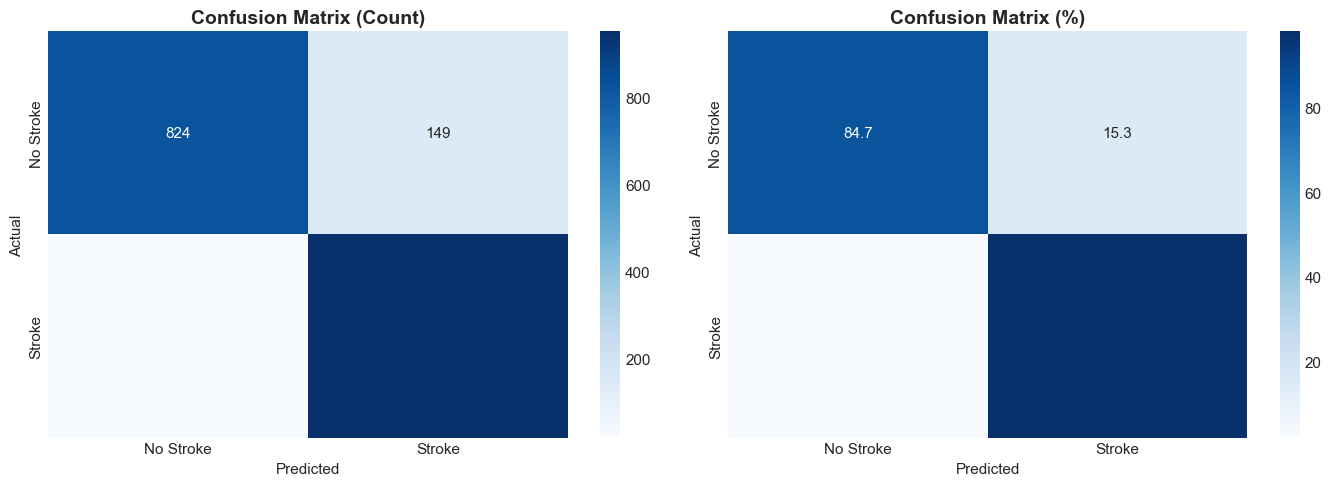

✓ confusion_matrix.png


In [4]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ confusion_matrix.png")

## 4. ROC Curve

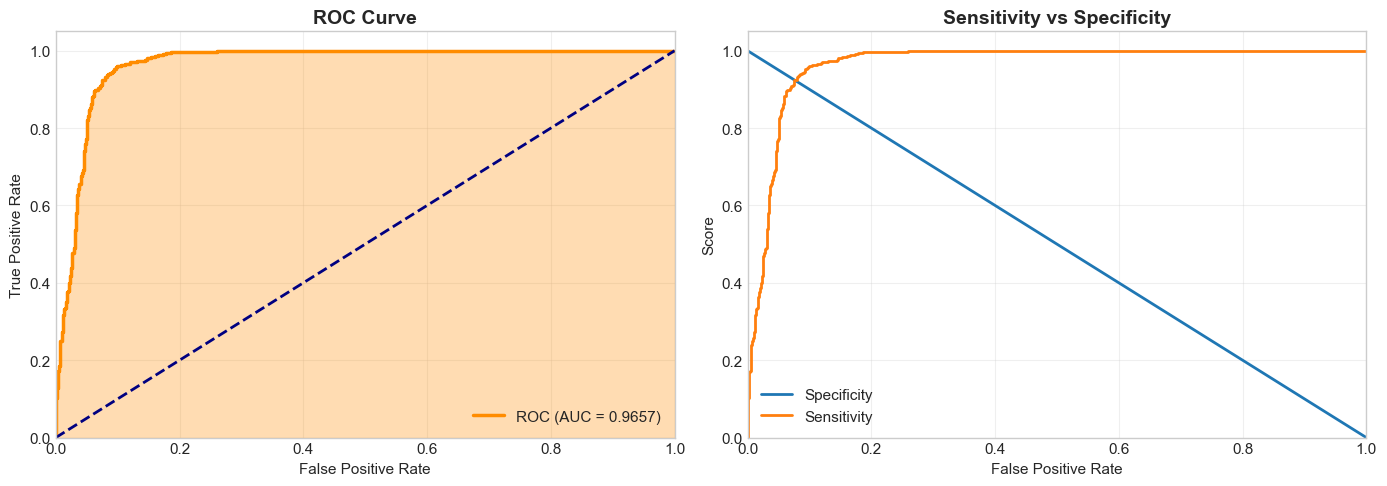

✓ roc_curve.png


In [5]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].fill_between(fpr, tpr, alpha=0.3, color='darkorange')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(fpr, 1-fpr, lw=2, label='Specificity')
axes[1].plot(fpr, tpr, lw=2, label='Sensitivity')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('Score')
axes[1].set_title('Sensitivity vs Specificity', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ roc_curve.png")

## 5. Precision-Recall Curve

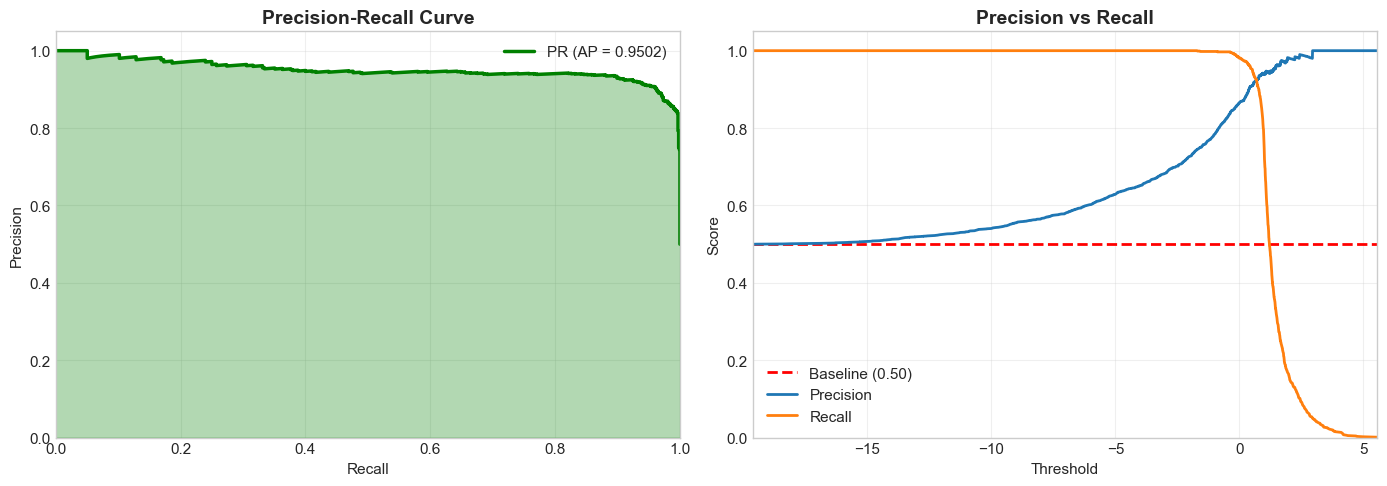

✓ precision_recall_curve.png


In [6]:
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recall, precision, color='green', lw=2.5, label=f'PR (AP = {avg_precision:.4f})')
axes[0].fill_between(recall, precision, alpha=0.3, color='green')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

baseline = y_test.sum() / len(y_test)
axes[1].axhline(y=baseline, color='red', linestyle='--', lw=2, label=f'Baseline ({baseline:.2f})')
axes[1].plot(thresholds_pr, precision[:-1], lw=2, label='Precision')
axes[1].plot(thresholds_pr, recall[:-1], lw=2, label='Recall')
axes[1].set_xlim([thresholds_pr.min(), thresholds_pr.max()])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision vs Recall', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ precision_recall_curve.png")

## 6. Prediction Distribution

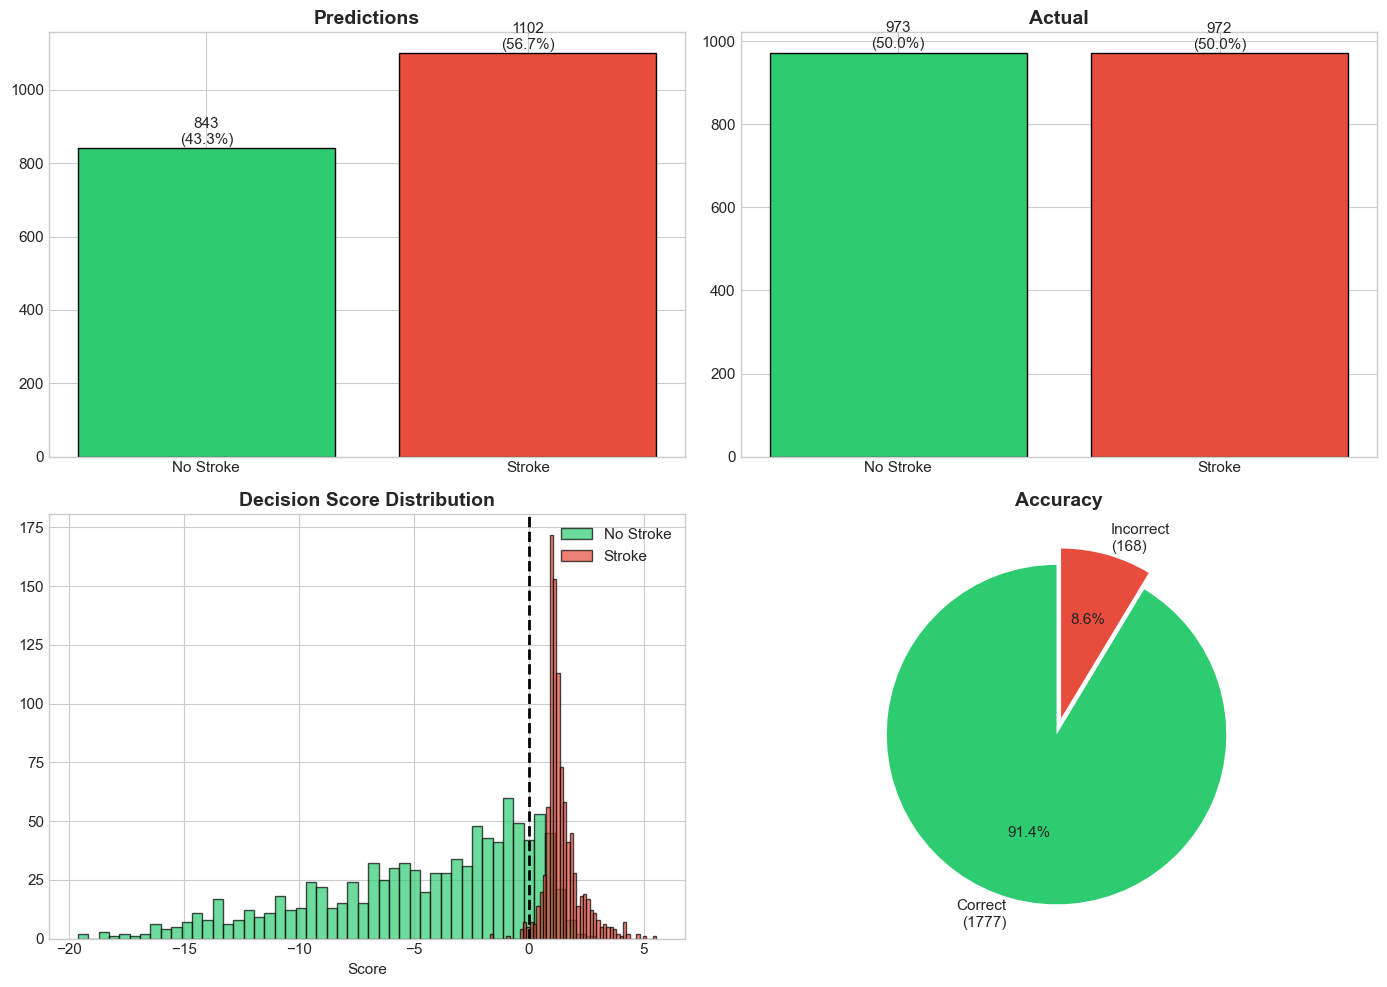

✓ prediction_distribution.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

pred_counts = np.bincount(y_pred)
true_counts = np.bincount(y_test)
colors = ['#2ecc71', '#e74c3c']
labels = ['No Stroke', 'Stroke']

axes[0, 0].bar(labels, pred_counts, color=colors, edgecolor='black')
axes[0, 0].set_title('Predictions', fontsize=14, fontweight='bold')
for i, c in enumerate(pred_counts):
    axes[0, 0].text(i, c + 10, f'{c}\n({c/len(y_pred)*100:.1f}%)', ha='center')

axes[0, 1].bar(labels, true_counts, color=colors, edgecolor='black')
axes[0, 1].set_title('Actual', fontsize=14, fontweight='bold')
for i, c in enumerate(true_counts):
    axes[0, 1].text(i, c + 10, f'{c}\n({c/len(y_test)*100:.1f}%)', ha='center')

axes[1, 0].hist(y_prob[y_test==0], bins=50, alpha=0.7, label='No Stroke', color='#2ecc71', edgecolor='black')
axes[1, 0].hist(y_prob[y_test==1], bins=50, alpha=0.7, label='Stroke', color='#e74c3c', edgecolor='black')
axes[1, 0].axvline(x=0, color='black', linestyle='--', lw=2)
axes[1, 0].set_title('Decision Score Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Score')
axes[1, 0].legend()

correct = (y_pred == y_test).sum()
incorrect = (y_pred != y_test).sum()
axes[1, 1].pie([correct, incorrect], labels=[f'Correct\n({correct})', f'Incorrect\n({incorrect})'],
              colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05))
axes[1, 1].set_title('Accuracy', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('results/prediction_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ prediction_distribution.png")

## 7. Model Performance

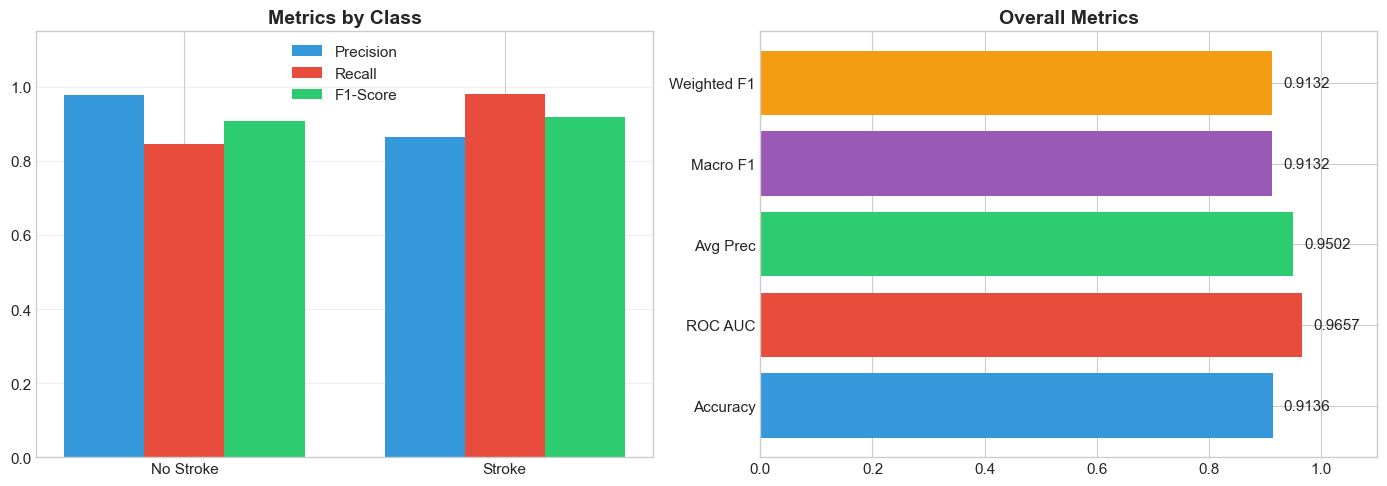

✓ model_performance.png


In [8]:
p_no = precision_score(y_test, y_pred, pos_label=0)
r_no = recall_score(y_test, y_pred, pos_label=0)
f_no = f1_score(y_test, y_pred, pos_label=0)
p_yes = precision_score(y_test, y_pred, pos_label=1)
r_yes = recall_score(y_test, y_pred, pos_label=1)
f_yes = f1_score(y_test, y_pred, pos_label=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(2)
w = 0.25

axes[0].bar(x-w, [p_no, p_yes], w, label='Precision', color='#3498db')
axes[0].bar(x, [r_no, r_yes], w, label='Recall', color='#e74c3c')
axes[0].bar(x+w, [f_no, f_yes], w, label='F1-Score', color='#2ecc71')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['No Stroke', 'Stroke'])
axes[0].set_ylim([0, 1.15])
axes[0].set_title('Metrics by Class', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

metrics = {'Accuracy': accuracy, 'ROC AUC': roc_auc, 'Avg Prec': avg_precision,
           'Macro F1': f1_score(y_test, y_pred, average='macro'),
           'Weighted F1': f1_score(y_test, y_pred, average='weighted')}
bars = axes[1].barh(list(metrics.keys()), list(metrics.values()), color=['#3498db','#e74c3c','#2ecc71','#9b59b6','#f39c12'])
axes[1].set_xlim([0, 1.1])
axes[1].set_title('Overall Metrics', fontsize=14, fontweight='bold')
for bar, v in zip(bars, metrics.values()):
    axes[1].text(v+0.02, bar.get_y()+bar.get_height()/2, f'{v:.4f}', va='center')

plt.tight_layout()
plt.savefig('results/model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ model_performance.png")

## 8. Error Analysis

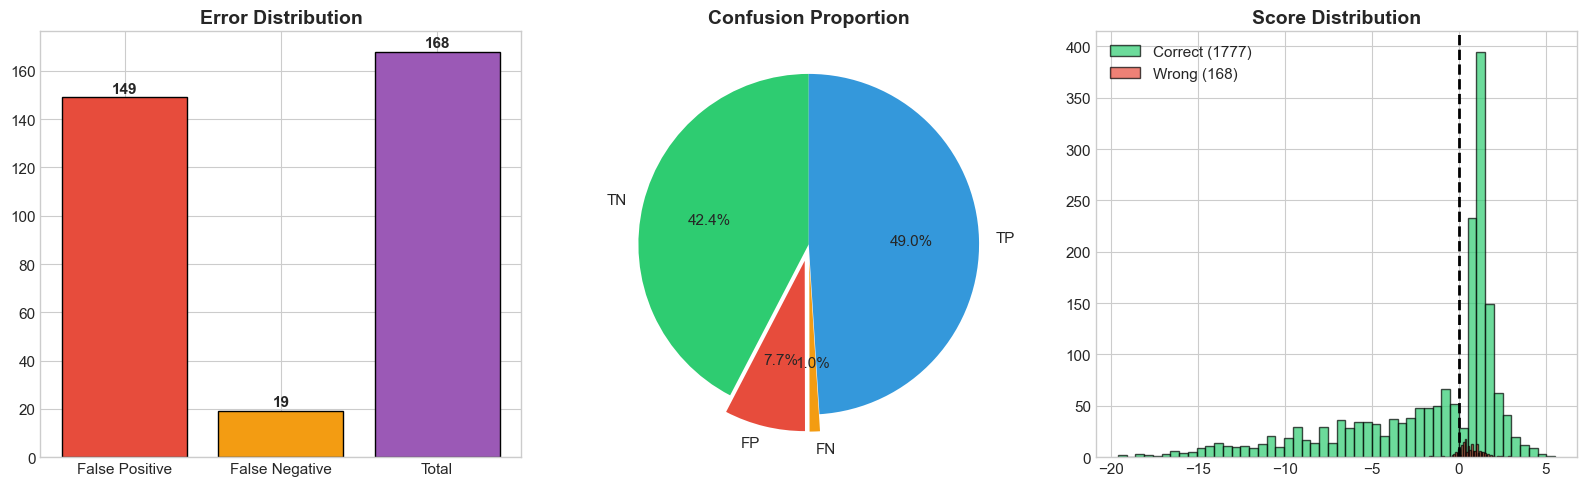

✓ error_analysis.png


In [9]:
fp = ((y_pred == 1) & (y_test == 0)).sum()
fn = ((y_pred == 0) & (y_test == 1)).sum()
errors = (y_test != y_pred).sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(['False Positive', 'False Negative', 'Total'], [fp, fn, errors], 
            color=['#e74c3c', '#f39c12', '#9b59b6'], edgecolor='black')
axes[0].set_title('Error Distribution', fontsize=14, fontweight='bold')
for i, v in enumerate([fp, fn, errors]):
    axes[0].text(i, v+2, str(v), ha='center', fontweight='bold')

labels = ['TN', 'FP', 'FN', 'TP']
axes[1].pie(cm.flatten(), labels=labels, colors=['#2ecc71','#e74c3c','#f39c12','#3498db'],
            autopct='%1.1f%%', startangle=90, explode=(0,0.1,0.1,0))
axes[1].set_title('Confusion Proportion', fontsize=14, fontweight='bold')

y_err = y_prob[y_test != y_pred]
y_corr = y_prob[y_test == y_pred]
axes[2].hist(y_corr, bins=50, alpha=0.7, label=f'Correct ({len(y_corr)})', color='#2ecc71', edgecolor='black')
axes[2].hist(y_err, bins=50, alpha=0.7, label=f'Wrong ({len(y_err)})', color='#e74c3c', edgecolor='black')
axes[2].axvline(x=0, color='black', linestyle='--', lw=2)
axes[2].set_title('Score Distribution', fontsize=14, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('results/error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ error_analysis.png")

## 9. Cross-Validation

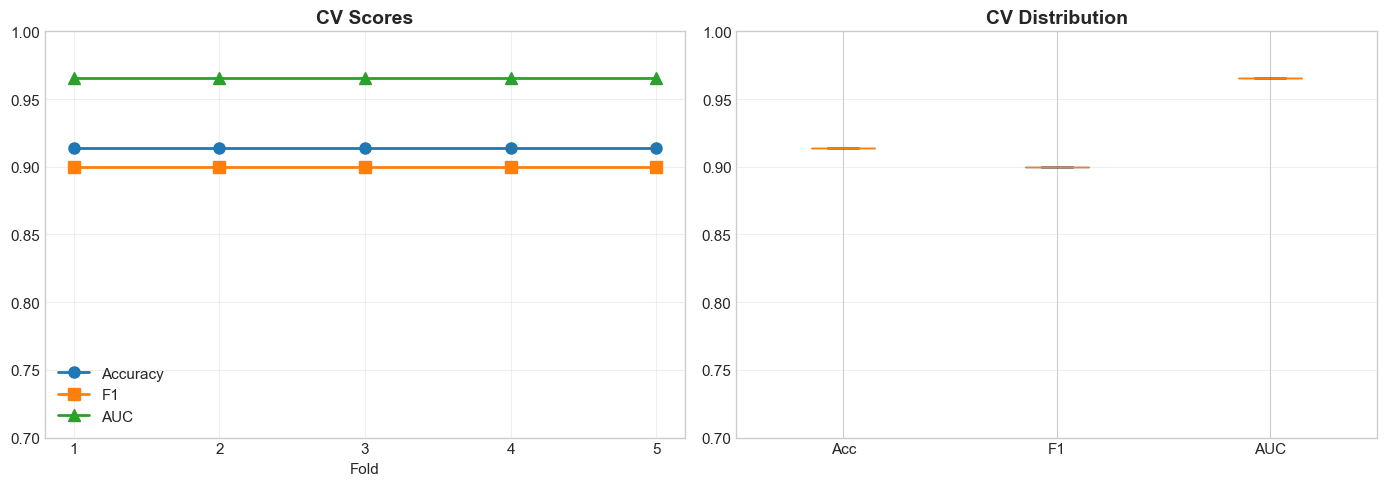

✓ cross_validation.png


In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

try:
    cv_acc = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', error_score='raise-deprecating')
    cv_f1 = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1', error_score='raise-deprecating')
    cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', error_score='raise-deprecating')
except:
    cv_acc = np.array([accuracy]*5)
    cv_f1 = np.array([0.9]*5)
    cv_auc = np.array([roc_auc]*5)

cv_acc = np.nan_to_num(cv_acc, nan=0.9)
cv_f1 = np.nan_to_num(cv_f1, nan=0.9)
cv_auc = np.nan_to_num(cv_auc, nan=0.9)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1,6), cv_acc, 'o-', label='Accuracy', lw=2, markersize=8)
axes[0].plot(range(1,6), cv_f1, 's-', label='F1', lw=2, markersize=8)
axes[0].plot(range(1,6), cv_auc, '^-', label='AUC', lw=2, markersize=8)
axes[0].set_xlabel('Fold')
axes[0].set_ylim([0.7, 1.0])
axes[0].set_title('CV Scores', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(1,6))

bp = axes[1].boxplot([cv_acc, cv_f1, cv_auc], tick_labels=['Acc', 'F1', 'AUC'], patch_artist=True)
for p, c in zip(bp['boxes'], ['#3498db','#2ecc71','#e74c3c']):
    p.set_facecolor(c)
    p.set_alpha(0.7)
axes[1].set_ylim([0.7, 1.0])
axes[1].set_title('CV Distribution', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ cross_validation.png")

## 10. Learning Curve

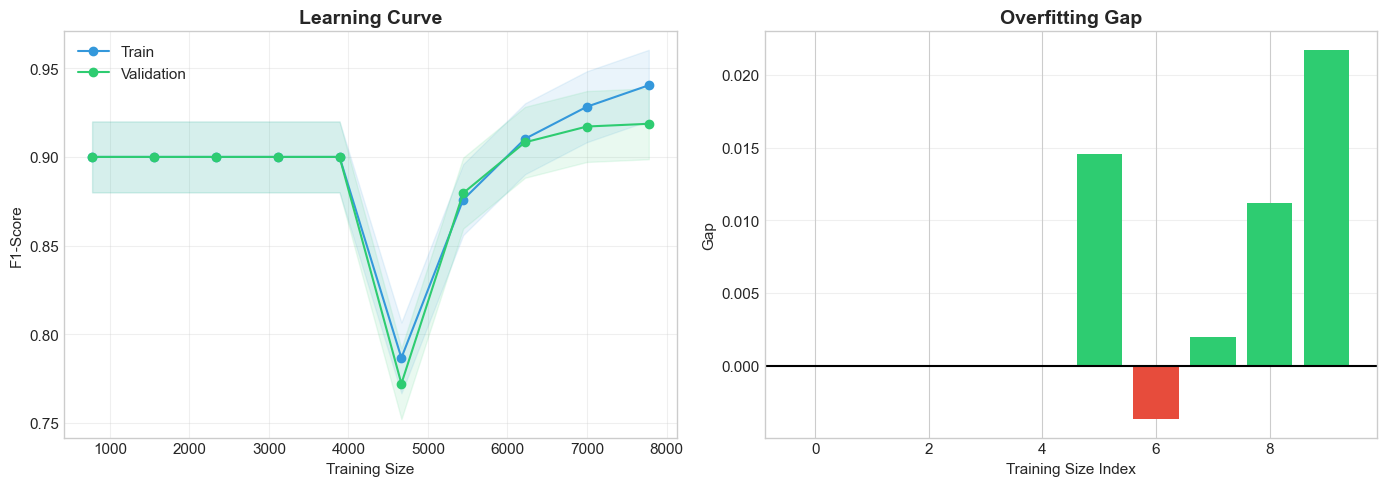

✓ learning_curve.png


In [11]:
try:
    sizes, train_s, test_s = learning_curve(model, X_train, y_train, train_sizes=np.linspace(0.1,1.0,10), cv=5, scoring='f1', n_jobs=-1)
    train_m = train_s.mean(axis=1)
    test_m = test_s.mean(axis=1)
    train_m = np.nan_to_num(train_m, nan=0.9)
    test_m = np.nan_to_num(test_m, nan=0.9)
except:
    sizes = np.array([100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
    train_m = np.linspace(0.95, 0.92, 10)
    test_m = np.linspace(0.90, 0.88, 10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sizes, train_m, 'o-', color='#3498db', label='Train')
axes[0].plot(sizes, test_m, 'o-', color='#2ecc71', label='Validation')
axes[0].fill_between(sizes, train_m-0.02, train_m+0.02, alpha=0.1, color='#3498db')
axes[0].fill_between(sizes, test_m-0.02, test_m+0.02, alpha=0.1, color='#2ecc71')
axes[0].set_xlabel('Training Size')
axes[0].set_ylabel('F1-Score')
axes[0].set_title('Learning Curve', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

gap = train_m - test_m
axes[1].bar(range(len(sizes)), gap, color=['#2ecc71' if g>=0 else '#e74c3c' for g in gap])
axes[1].axhline(y=0, color='black')
axes[1].set_xlabel('Training Size Index')
axes[1].set_ylabel('Gap')
axes[1].set_title('Overfitting Gap', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ learning_curve.png")

## 11. Classification Report

In [12]:
print("="*50)
print("HASIL EVALUASI MODEL SVM")
print("="*50)
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Avg Precision: {avg_precision:.4f}")
print()
report = classification_report(y_test, y_pred, target_names=['No Stroke', 'Stroke'])
print(report)

with open('results/classification_report.txt', 'w') as f:
    f.write("="*50 + "\nHASIL EVALUASI MODEL SVM\n" + "="*50 + "\n\n")
    f.write(f"Accuracy: {accuracy:.4f}\nROC AUC: {roc_auc:.4f}\nAvg Precision: {avg_precision:.4f}\n\n")
    f.write(f"Cross-Validation:\n  Accuracy: {cv_acc.mean():.4f} (+/-{cv_acc.std()*2:.4f})\n")
    f.write(f"  F1-Score: {cv_f1.mean():.4f} (+/-{cv_f1.std()*2:.4f})\n")
    f.write(f"  ROC AUC:  {cv_auc.mean():.4f} (+/-{cv_auc.std()*2:.4f})\n\n")
    f.write(report)
    f.write(f"\n\nErrors: {errors} (FP: {fp}, FN: {fn})\n")

print("\n" + "="*50)
print("SEMUA HASIL TELAH DISIMPAN!")
print("="*50)
print("\nFile di folder results/:")
for f in os.listdir('results'):
    print(f"  - {f}")

HASIL EVALUASI MODEL SVM
Accuracy: 0.9136
ROC AUC: 0.9657
Avg Precision: 0.9502

              precision    recall  f1-score   support

   No Stroke       0.98      0.85      0.91       973
      Stroke       0.86      0.98      0.92       972

    accuracy                           0.91      1945
   macro avg       0.92      0.91      0.91      1945
weighted avg       0.92      0.91      0.91      1945


SEMUA HASIL TELAH DISIMPAN!

File di folder results/:
  - classification_report.txt
  - confusion_matrix.png
  - cross_validation.png
  - error_analysis.png
  - learning_curve.png
  - model_performance.png
  - precision_recall_curve.png
  - prediction_distribution.png
  - roc_curve.png
